In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('cleaned_drilling_data.csv')

In [3]:
print("Loaded! Shape:",df.shape)
print('\nColumns:')
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Loaded! Shape: (600359, 35)

Columns:
['time', 'block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque', 'drill_mode', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week']

First 5 Rows:


,time,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,minute,day_of_week
0,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
1,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
2,2020-10-25 12:38:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,38,6
3,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6
4,2020-10-25 12:39:00,43.596,46.95761,123.8774,0.0,0.0,0.0,0.31182,0.0,57.19964,...,7389.89,-524.992325,-7433.422,0.0,2020,10,25,12,39,6


# Target Investigation

In [4]:
target = "top_drive_torque_ft_lbs"

print("Target Variable:", target)
print()
print(df[target].describe())

Target Variable: top_drive_torque_ft_lbs

count    600359.000000
mean       1184.602275
std        1988.148307
min           0.000000
25%           0.000000
50%           0.000000
75%        2112.692600
max        5422.641500
Name: top_drive_torque_ft_lbs, dtype: float64


In [5]:
#Checking Missing Values 
print("Missing values:", df[target].isnull().sum())

Missing values: 0


In [6]:
# Checking Zero Values
zero_count = (df[target] == 0).sum()

print("Total observations:", len(df))
print("Zero Top Drive Torque:", zero_count)

percentage = (df[target] == 0).mean() * 100

print(f"Percentage of zero Top Drive Torque: {percentage:.2f}%")

Total observations: 600359
Zero Top Drive Torque: 408613
Percentage of zero Top Drive Torque: 68.06%


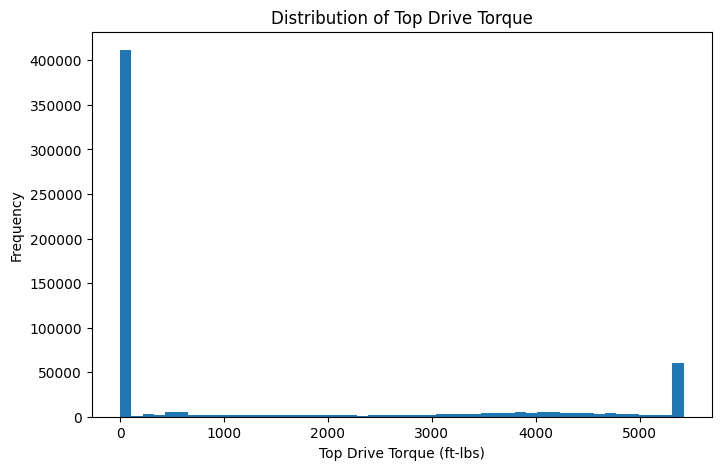

In [7]:
# Histogram 
df[target].plot(
    kind="hist",
    bins=50,
    figsize=(8, 5)
)

plt.xlabel("Top Drive Torque (ft-lbs)")
plt.ylabel("Frequency")
plt.title("Distribution of Top Drive Torque")

plt.show()

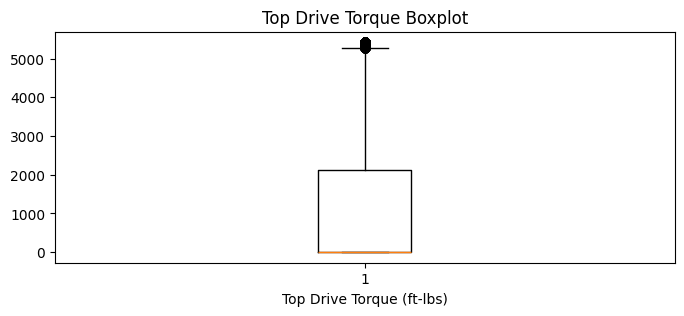

In [8]:
# Outlier Investigation
plt.figure(figsize=(8, 3))

plt.boxplot(df[target])

plt.xlabel("Top Drive Torque (ft-lbs)")
plt.title("Top Drive Torque Boxplot")

plt.show()

# The boxplot shows that Top Drive Torque has a large concentration of values at 0 ft-lbs. The non-zero values have a wide range, with the main distribution extending up to around 2,100 ft-lbs. A few values appear near 5,300–5,400 ft-lbs, which are shown as potential outliers by the boxplot.

In [9]:
# Percentile Analysis

percentiles = df[target].quantile([0.95, 0.99, 0.995, 0.999])

print("Top Drive Torque Percentile Analysis")
print("-" * 40)

print(f"95th Percentile  : {percentiles[0.95]:.2f} ft-lbs")
print(f"99th Percentile  : {percentiles[0.99]:.2f} ft-lbs")
print(f"99.5th Percentile: {percentiles[0.995]:.2f} ft-lbs")
print(f"99.9th Percentile: {percentiles[0.999]:.2f} ft-lbs")

print(f"\nMaximum Torque   : {df[target].max():.2f} ft-lbs")

Top Drive Torque Percentile Analysis
----------------------------------------
95th Percentile  : 5422.64 ft-lbs
99th Percentile  : 5422.64 ft-lbs
99.5th Percentile: 5422.64 ft-lbs
99.9th Percentile: 5422.64 ft-lbs

Maximum Torque   : 5422.64 ft-lbs


In [10]:
# Check how many observations are exactly at the maximum torque

max_torque = df[target].max()
max_count = (df[target] == max_torque).sum()
max_percentage = (df[target] == max_torque).mean() * 100

print("Maximum Top Drive Torque:", max_torque)
print("Number of observations at maximum:", max_count)
print(f"Percentage at maximum: {max_percentage:.2f}%")

Maximum Top Drive Torque: 5422.6415
Number of observations at maximum: 58519
Percentage at maximum: 9.75%


# The percentile analysis shows that the 95th, 99th, 99.5th, and 99.9th percentiles are all equal to the maximum Top Drive Torque value of 5,422.64 ft-lbs. Further investigation shows that 58,519 observations (9.75% of the dataset) have exactly this maximum value. This indicates a substantial concentration of observations at the upper boundary of the recorded torque range.

In [11]:
features = [
    "weight_on_bit",
    "top_drive_rpm",
    "flow_in",
    "hookload",
    "total_depth",
    "block_position",
    "mwd_inclination",
    "mwd_azimuth",
    "rop_depth_hour"
]

target = "top_drive_torque_ft_lbs"

X = df[features].copy()
y = df[target].copy()

In [12]:
print("Features:")
for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

print("\nTarget:", target)

Features:
1. weight_on_bit
2. top_drive_rpm
3. flow_in
4. hookload
5. total_depth
6. block_position
7. mwd_inclination
8. mwd_azimuth
9. rop_depth_hour

Target: top_drive_torque_ft_lbs


In [13]:
zero_count = (y == 0).sum()
nonzero_count = (y != 0).sum()

print("Zero torque:", zero_count)
print("Non-zero torque:", nonzero_count)

print(f"Zero percentage: {zero_count / len(y) * 100:.2f}%")
print(f"Non-zero percentage: {nonzero_count / len(y) * 100:.2f}%")

Zero torque: 408613
Non-zero torque: 191746
Zero percentage: 68.06%
Non-zero percentage: 31.94%


In [14]:
print("\nTop target values:")
print(y.value_counts().head(15))


Top target values:
top_drive_torque_ft_lbs
0.00000       408613
5422.64150     58519
0.77642          550
2.80127          426
4.82612          273
6.85096          189
561.48605        141
565.53795        137
4167.91300       132
4169.93800       131
559.46011        129
567.56389        126
4165.88800       125
563.51200        125
3773.06760       124
Name: count, dtype: int64


In [15]:
print("\nTarget percentiles:")
print(y.quantile([0, .25, .50, .75, .90, .95, .99, .995, .999, 1]))


Target percentiles:
0.000       0.0000
0.250       0.0000
0.500       0.0000
0.750    2112.6926
0.900    5324.1010
0.950    5422.6415
0.990    5422.6415
0.995    5422.6415
0.999    5422.6415
1.000    5422.6415
Name: top_drive_torque_ft_lbs, dtype: float64


In [16]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("Rows:", len(df))
print("Columns:", len(df.columns))

# Missing values
print("\nMissing values:")
print(df[features + [target]].isnull().sum())

# Infinite values
print("\nInfinite values:")
print(np.isinf(df[features + [target]]).sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Duplicate timestamps
print("Duplicate timestamps:", df["time"].duplicated().sum())

# Timestamp ordering
print("\nTimestamp sorted:", df["time"].is_monotonic_increasing)

# Target NaNs
print("\nTarget NaNs:", df[target].isna().sum())

DATA QUALITY CHECK
Rows: 600359
Columns: 35

Missing values:
weight_on_bit              0
top_drive_rpm              0
flow_in                    0
hookload                   0
total_depth                0
block_position             0
mwd_inclination            0
mwd_azimuth                0
rop_depth_hour             0
top_drive_torque_ft_lbs    0
dtype: int64

Infinite values:
weight_on_bit              0
top_drive_rpm              0
flow_in                    0
hookload                   0
total_depth                0
block_position             0
mwd_inclination            0
mwd_azimuth                0
rop_depth_hour             0
top_drive_torque_ft_lbs    0
dtype: int64

Duplicate rows: 22
Duplicate timestamps: 497459

Timestamp sorted: False

Target NaNs: 0


In [17]:
# ============================================================
# CHRONOLOGICAL 80 / 20 TRAIN-TEST SPLIT
# ============================================================
#
# The dataset is sorted chronologically before splitting.
#
# 80% -> Training
# 20% -> Final Test
#
# The final 20% represents future/unseen observations.
# ============================================================

# Ensure timestamp is datetime
df["time"] = pd.to_datetime(df["time"])

# Sort chronologically
df = df.sort_values("time").reset_index(drop=True)

# Feature matrix and target
X = df[features].copy()
y = df[target].copy()

# Calculate split point
n = len(df)

train_end = int(n * 0.80)

# ------------------------------------------------------------
# Training data: first 80%
# ------------------------------------------------------------

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

# ------------------------------------------------------------
# Test data: final 20%
# ------------------------------------------------------------

X_test = X.iloc[train_end:].copy()
y_test = y.iloc[train_end:].copy()

# ============================================================
# DISPLAY SPLIT INFORMATION
# ============================================================

print("=" * 70)
print("CHRONOLOGICAL 80 / 20 TRAIN-TEST SPLIT")
print("=" * 70)

print(f"Total samples : {n:,}")

print(
    f"Training      : {len(X_train):,} "
    f"({len(X_train) / n * 100:.1f}%)"
)

print(
    f"Test          : {len(X_test):,} "
    f"({len(X_test) / n * 100:.1f}%)"
)

print("\nTraining period:")
print(
    df["time"].iloc[0],
    "→",
    df["time"].iloc[train_end - 1]
)

print("\nTest period:")
print(
    df["time"].iloc[train_end],
    "→",
    df["time"].iloc[-1]
)

CHRONOLOGICAL 80 / 20 TRAIN-TEST SPLIT
Total samples : 600,359
Training      : 480,287 (80.0%)
Test          : 120,072 (20.0%)

Training period:
2020-10-25 12:38:00 → 2020-12-22 02:26:00

Test period:
2020-12-22 02:26:00 → 2021-01-05 11:01:00


In [18]:
if not df["time"].is_monotonic_increasing:
    raise ValueError("Data is not sorted chronologically!")

print("✓ Data is correctly sorted chronologically.")

✓ Data is correctly sorted chronologically.


In [19]:
# ============================================================
# TARGET DISTRIBUTION: TRAIN VS TEST
# ============================================================

print("=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

for name, data in [
    ("TRAIN", y_train),
    ("TEST", y_test)
]:

    print("\n" + name)
    print("-" * 50)

    print(f"Samples : {len(data):,}")
    print(f"Mean    : {data.mean():.4f}")
    print(f"Std     : {data.std():.4f}")
    print(f"Median  : {data.median():.4f}")
    print(f"Min     : {data.min():.4f}")
    print(f"Max     : {data.max():.4f}")
    print(f"Zero %  : {(data == 0).mean() * 100:.2f}%")

TARGET DISTRIBUTION

TRAIN
--------------------------------------------------
Samples : 480,287
Mean    : 1351.3779
Std     : 2079.9017
Median  : 0.0000
Min     : 0.0000
Max     : 5422.6415
Zero %  : 64.03%

TEST
--------------------------------------------------
Samples : 120,072
Mean    : 517.5010
Std     : 1379.6541
Median  : 0.0000
Min     : 0.0000
Max     : 5422.6415
Zero %  : 84.21%


## 6. Model Training and Evaluation Strategy

Four regression algorithms are evaluated using the same feature set and chronological development split:

1. Random Forest
2. XGBoost
3. LightGBM
4. CatBoost

The dataset is divided chronologically into:

- **70% internal training**
- **10% internal validation**
- **20% final test**

The four baseline models are trained on the internal training period and evaluated on the same internal validation period.

The internal validation results are used to select the best-performing model family for further hyperparameter optimization.

The final 20% chronological test set is reserved for the final evaluation of the selected model and is not used during model selection or hyperparameter tuning.

The primary model-selection metric is RMSE, while MAE and R² are also reported.

## Internal Development Split for Model Selection

The dataset is divided chronologically into an 80% development set and a 20% final test set.

The 20% final test set is reserved exclusively for the final evaluation and is not used for model selection or hyperparameter tuning.

The 80% development set is further divided chronologically into:

- 70% of the complete dataset for internal model training
- 10% of the complete dataset for internal validation

The internal validation period is used to compare the four candidate regression models and select the model family for further optimization.

This preserves the final 20% test set as an unseen chronological holdout.

In [20]:
# ============================================================
# INTERNAL DEVELOPMENT TRAIN / VALIDATION SPLIT
# ============================================================
#
# Overall dataset:
#   70% -> Internal training
#   10% -> Internal validation
#   20% -> Final test
#
# The final 20% test set is NOT used for model selection.
# ============================================================

development_end = len(X_train)

internal_train_end = int(
    development_end * (70 / 80)
)

# ------------------------------------------------------------
# Internal training
# ------------------------------------------------------------

X_dev_train = X_train.iloc[
    :internal_train_end
].copy()

y_dev_train = y_train.iloc[
    :internal_train_end
].copy()

# ------------------------------------------------------------
# Internal validation
# ------------------------------------------------------------

X_dev_val = X_train.iloc[
    internal_train_end:
].copy()

y_dev_val = y_train.iloc[
    internal_train_end:
].copy()

print("=" * 70)
print("INTERNAL DEVELOPMENT SPLIT")
print("=" * 70)

print(
    f"Internal training   : "
    f"{len(X_dev_train):,}"
)

print(
    f"Internal validation : "
    f"{len(X_dev_val):,}"
)

print(
    f"Final test          : "
    f"{len(X_test):,}"
)

print("\nOverall split:")
print("70% internal training")
print("10% internal validation")
print("20% final test")

INTERNAL DEVELOPMENT SPLIT
Internal training   : 420,251
Internal validation : 60,036
Final test          : 120,072

Overall split:
70% internal training
10% internal validation
20% final test


## 6.1 Random Forest Regression

Random Forest is used as a tree-based ensemble baseline.

The model combines predictions from multiple decision trees and can capture nonlinear relationships between drilling parameters and top drive torque.

The model is trained using the internal training portion of the 80% development dataset and evaluated on the chronological internal validation period.

The final 20% test set is not used during baseline model comparison.

In [21]:
# ============================================================
# RANDOM FOREST - INTERNAL VALIDATION
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train only on internal training data
rf_model.fit(
    X_dev_train,
    y_dev_train
)

# Predict internal validation period
rf_val_pred = rf_model.predict(
    X_dev_val
)

# Validation metrics
rf_val_mae = mean_absolute_error(
    y_dev_val,
    rf_val_pred
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_dev_val,
        rf_val_pred
    )
)

rf_val_r2 = r2_score(
    y_dev_val,
    rf_val_pred
)

print("=" * 70)
print("RANDOM FOREST - INTERNAL VALIDATION")
print("=" * 70)

print(f"MAE  : {rf_val_mae:.4f}")
print(f"RMSE : {rf_val_rmse:.4f}")
print(f"R²   : {rf_val_r2:.4f}")

RANDOM FOREST - INTERNAL VALIDATION
MAE  : 360.5961
RMSE : 806.2102
R²   : 0.9027


## 6.2 XGBoost Regression

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each new tree attempting to reduce the errors of the previous trees.

The model is trained using the internal training portion of the 80% development dataset and evaluated on the same chronological internal validation period used for the other baseline models.

The final 20% test set remains untouched during model selection.

In [22]:
# ============================================================
# XGBOOST - INTERNAL VALIDATION
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train on internal training data
xgb_model.fit(
    X_dev_train,
    y_dev_train
)

# Predict internal validation period
xgb_val_pred = xgb_model.predict(
    X_dev_val
)

# Validation metrics
xgb_val_mae = mean_absolute_error(
    y_dev_val,
    xgb_val_pred
)

xgb_val_rmse = np.sqrt(
    mean_squared_error(
        y_dev_val,
        xgb_val_pred
    )
)

xgb_val_r2 = r2_score(
    y_dev_val,
    xgb_val_pred
)

print("=" * 70)
print("XGBOOST - INTERNAL VALIDATION")
print("=" * 70)

print(f"MAE  : {xgb_val_mae:.4f}")
print(f"RMSE : {xgb_val_rmse:.4f}")
print(f"R²   : {xgb_val_r2:.4f}")

XGBOOST - INTERNAL VALIDATION
MAE  : 364.1523
RMSE : 729.6746
R²   : 0.9203


## 6.3 LightGBM Regression

LightGBM is another gradient boosting algorithm designed for efficient training on large datasets.

Because this dataset contains hundreds of thousands of observations, LightGBM provides an efficient alternative to conventional tree-based ensemble methods.

In [23]:
# ============================================================
# LIGHTGBM - INTERNAL VALIDATION
# ============================================================

lgbm_model = LGBMRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train on internal training data
lgbm_model.fit(
    X_dev_train,
    y_dev_train
)

# Predict internal validation period
lgbm_val_pred = lgbm_model.predict(
    X_dev_val
)

# Validation metrics
lgbm_val_mae = mean_absolute_error(
    y_dev_val,
    lgbm_val_pred
)

lgbm_val_rmse = np.sqrt(
    mean_squared_error(
        y_dev_val,
        lgbm_val_pred
    )
)

lgbm_val_r2 = r2_score(
    y_dev_val,
    lgbm_val_pred
)

print("=" * 70)
print("LIGHTGBM - INTERNAL VALIDATION")
print("=" * 70)

print(f"MAE  : {lgbm_val_mae:.4f}")
print(f"RMSE : {lgbm_val_rmse:.4f}")
print(f"R²   : {lgbm_val_r2:.4f}")

LIGHTGBM - INTERNAL VALIDATION
MAE  : 299.7858
RMSE : 634.3206
R²   : 0.9398


## 6.4 CatBoost Regression

CatBoost is evaluated as the fourth tree-based regression model.

The model is trained using the internal training portion of the 80% development dataset and evaluated on the chronological internal validation period.

CatBoost achieves the strongest baseline validation performance and is therefore selected for hyperparameter optimization.

The final 20% test set remains untouched during model selection and hyperparameter tuning.

In [24]:
# ============================================================
# CATBOOST BASELINE - INTERNAL VALIDATION
# ============================================================

cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

# Train on internal training data
cat_model.fit(
    X_dev_train,
    y_dev_train
)

# Predict internal validation period
cat_val_pred = cat_model.predict(
    X_dev_val
)

# Validation metrics
cat_val_mae = mean_absolute_error(
    y_dev_val,
    cat_val_pred
)

cat_val_rmse = np.sqrt(
    mean_squared_error(
        y_dev_val,
        cat_val_pred
    )
)

cat_val_r2 = r2_score(
    y_dev_val,
    cat_val_pred
)

print("=" * 70)
print("CATBOOST BASELINE - INTERNAL VALIDATION")
print("=" * 70)

print(f"MAE  : {cat_val_mae:.4f}")
print(f"RMSE : {cat_val_rmse:.4f}")
print(f"R²   : {cat_val_r2:.4f}")

CATBOOST BASELINE - INTERNAL VALIDATION
MAE  : 243.8739
RMSE : 584.2158
R²   : 0.9489


## Baseline Model Comparison

The four candidate regression models are compared using the same chronological internal validation period.

The final 20% test set is not used for model selection.

The model with the strongest validation performance is selected for hyperparameter optimization.

Validation RMSE is used as the primary selection metric because it places greater emphasis on large prediction errors, while MAE and R² are also reported.

In [25]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================
#
# IMPORTANT:
# The final 20% test set is NOT used here.
# Model selection occurs using internal validation only.
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "MAE": [
        rf_val_mae,
        xgb_val_mae,
        lgbm_val_mae,
        cat_val_mae
    ],

    "RMSE": [
        rf_val_rmse,
        xgb_val_rmse,
        lgbm_val_rmse,
        cat_val_rmse
    ],

    "R2 Score": [
        rf_val_r2,
        xgb_val_r2,
        lgbm_val_r2,
        cat_val_r2
    ]
})

model_comparison = (
    model_comparison
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("BASELINE MODEL COMPARISON - INTERNAL VALIDATION")
print("=" * 70)

display(model_comparison)

BASELINE MODEL COMPARISON - INTERNAL VALIDATION


,Model,MAE,RMSE,R2 Score
0,CatBoost,243.873944,584.215809,0.948908
1,LightGBM,299.785759,634.320579,0.939768
2,XGBoost,364.152263,729.674553,0.920298
3,Random Forest,360.596069,806.210179,0.902702


## 8. CatBoost Hyperparameter Optimization

CatBoost achieved the strongest baseline performance among the evaluated regression models and was therefore selected for further hyperparameter optimization.

The original chronological 80/20 train-test split is preserved throughout the experiment.

To tune CatBoost without using the final test set, the 80% development data is divided chronologically into:

- **70% of the complete dataset:** Internal training
- **10% of the complete dataset:** Internal validation
- **20% of the complete dataset:** Final test

The final 20% test set remains completely untouched during hyperparameter optimization.

A randomized search of 20 CatBoost configurations is performed over the following parameters:

- Number of boosting iterations
- Tree depth
- Learning rate
- L2 regularization
- Random strength

Each configuration is evaluated using the internal validation set.

Validation RMSE is used as the primary criterion for selecting the best configuration, while MAE and R² are also recorded.

After selecting the best hyperparameters, the final CatBoost model is retrained using the complete 80% development dataset and evaluated once on the untouched 20% test set.

In [26]:
# ============================================================
# INTERNAL TRAIN / VALIDATION SPLIT FOR CATBOOST TUNING
# ============================================================
#
# The original chronological 80/20 split is preserved.
#
# The 20% test set remains completely untouched.
#
# Inside the 80% development data:
#   70% -> Internal training
#   10% -> Internal validation
#
# Overall:
#   70% -> Model training
#   10% -> Hyperparameter validation
#   20% -> Final test
# ============================================================

development_end = len(X_train)

internal_train_end = int(
    development_end * (70 / 80)
)

# ------------------------------------------------------------
# Internal training set
# ------------------------------------------------------------

X_tune_train = X_train.iloc[
    :internal_train_end
].copy()

y_tune_train = y_train.iloc[
    :internal_train_end
].copy()

# ------------------------------------------------------------
# Internal validation set
# ------------------------------------------------------------

X_tune_val = X_train.iloc[
    internal_train_end:
].copy()

y_tune_val = y_train.iloc[
    internal_train_end:
].copy()

print("=" * 70)
print("CATBOOST INTERNAL VALIDATION SPLIT")
print("=" * 70)

print(
    f"Internal training   : {len(X_tune_train):,}"
)

print(
    f"Internal validation : {len(X_tune_val):,}"
)

print(
    f"Final test          : {len(X_test):,}"
)

print("\nInternal training period:")
print(
    df["time"].iloc[0],
    "→",
    df["time"].iloc[internal_train_end - 1]
)

print("\nInternal validation period:")
print(
    df["time"].iloc[internal_train_end],
    "→",
    df["time"].iloc[train_end - 1]
)

print("\nFinal test period:")
print(
    df["time"].iloc[train_end],
    "→",
    df["time"].iloc[-1]
)

CATBOOST INTERNAL VALIDATION SPLIT
Internal training   : 420,251
Internal validation : 60,036
Final test          : 120,072

Internal training period:
2020-10-25 12:38:00 → 2020-12-15 01:48:00

Internal validation period:
2020-12-15 01:48:00 → 2020-12-22 02:26:00

Final test period:
2020-12-22 02:26:00 → 2021-01-05 11:01:00


In [27]:
# ============================================================
# CATBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================

from sklearn.model_selection import ParameterSampler
from scipy.stats import randint, loguniform, uniform

catboost_param_distributions = {

    # Number of boosting iterations
    "iterations": randint(300, 1001),

    # Tree depth / model complexity
    "depth": randint(6, 10),

    # Learning rate
    "learning_rate": loguniform(
        0.02,
        0.10
    ),

    # L2 regularization
    "l2_leaf_reg": loguniform(
        2,
        15
    ),

    # Randomness used during split selection
    "random_strength": uniform(
        0,
        2
    )
}

print("✓ CatBoost parameter space created")

✓ CatBoost parameter space created


In [28]:
# ============================================================
# GENERATE CATBOOST SEARCH CONFIGURATIONS
# ============================================================

N_ITERATIONS = 20

random_search_params = list(
    ParameterSampler(
        catboost_param_distributions,
        n_iter=N_ITERATIONS,
        random_state=42
    )
)

print("=" * 70)
print("CATBOOST RANDOMIZED SEARCH")
print("=" * 70)

print(
    f"Configurations to evaluate: {N_ITERATIONS}"
)

print("\nFinal 20% test set will NOT be used.")

CATBOOST RANDOMIZED SEARCH
Configurations to evaluate: 20

Final 20% test set will NOT be used.


In [29]:
# ============================================================
# CATBOOST HYPERPARAMETER TUNING
# ============================================================
#
# Each configuration:
#
#   TRAIN -> X_tune_train / y_tune_train
#   VALIDATE -> X_tune_val / y_tune_val
#   TEST -> NOT USED
#
# RMSE is used as the primary selection metric.
# ============================================================

tuning_results = []

best_model = None
best_params = None

best_rmse = float("inf")
best_mae = float("inf")
best_r2 = -float("inf")


for trial, params in enumerate(
    random_search_params,
    start=1
):

    print("\n" + "=" * 70)
    print(
        f"TRIAL {trial}/{N_ITERATIONS}"
    )
    print("=" * 70)

    print("Parameters:")

    for key, value in params.items():
        print(
            f"  {key}: {value}"
        )

    # --------------------------------------------------------
    # Create CatBoost model
    # --------------------------------------------------------

    model = CatBoostRegressor(
        **params,

        loss_function="RMSE",

        eval_metric="RMSE",

        random_seed=42,

        verbose=False,

        # Early stopping
        od_type="Iter",

        od_wait=75
    )

    # --------------------------------------------------------
    # Train on internal training data
    # --------------------------------------------------------

    model.fit(
        X_tune_train,
        y_tune_train,

        eval_set=(
            X_tune_val,
            y_tune_val
        ),

        use_best_model=True
    )

    # --------------------------------------------------------
    # Internal validation predictions
    # --------------------------------------------------------

    val_pred = model.predict(
        X_tune_val
    )

    # --------------------------------------------------------
    # Calculate validation metrics
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_tune_val,
        val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_tune_val,
            val_pred
        )
    )

    r2 = r2_score(
        y_tune_val,
        val_pred
    )

    best_iteration = (
        model.get_best_iteration()
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    result = {
        "Trial": trial,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Best_Iteration": best_iteration,
        **params
    }

    tuning_results.append(
        result
    )

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print("\nValidation Performance:")

    print(
        f"  MAE  : {mae:.4f}"
    )

    print(
        f"  RMSE : {rmse:.4f}"
    )

    print(
        f"  R²   : {r2:.4f}"
    )

    print(
        f"  Best iteration: "
        f"{best_iteration}"
    )

    # --------------------------------------------------------
    # Select best model
    # --------------------------------------------------------

    if rmse < best_rmse:

        best_rmse = rmse

        best_mae = mae

        best_r2 = r2

        best_model = model

        best_params = params.copy()

        print(
            "\n🏆 NEW BEST MODEL"
        )

        print(
            f"Best validation RMSE: "
            f"{best_rmse:.4f}"
        )


print("\n" + "=" * 70)
print("CATBOOST TUNING COMPLETED")
print("=" * 70)

print(
    f"Configurations evaluated: "
    f"{N_ITERATIONS}"
)

print("\nBest internal validation performance:")

print(
    f"MAE  : {best_mae:.4f}"
)

print(
    f"RMSE : {best_rmse:.4f}"
)

print(
    f"R²   : {best_r2:.4f}"
)

print("\nBest hyperparameters:")

for key, value in best_params.items():
    print(
        f"  {key}: {value}"
    )


TRIAL 1/20
Parameters:
  depth: 8
  iterations: 735
  l2_leaf_reg: 13.581985352179869
  learning_rate: 0.06496385739540578
  random_strength: 1.1973169683940732

Validation Performance:
  MAE  : 221.7450
  RMSE : 572.6443
  R²   : 0.9509
  Best iteration: 247

🏆 NEW BEST MODEL
Best validation RMSE: 572.6443

TRIAL 2/20
Parameters:
  depth: 8
  iterations: 421
  l2_leaf_reg: 2.7386388058464264
  learning_rate: 0.021959816073193316
  random_strength: 1.7323522915498704

Validation Performance:
  MAE  : 222.1217
  RMSE : 581.8849
  R²   : 0.9493
  Best iteration: 383

TRIAL 3/20
Parameters:
  depth: 9
  iterations: 963
  l2_leaf_reg: 7.423304665511389
  learning_rate: 0.02190080091336961
  random_strength: 1.4439975445336495

Validation Performance:
  MAE  : 224.4833
  RMSE : 577.4647
  R²   : 0.9501
  Best iteration: 650

TRIAL 4/20
Parameters:
  depth: 7
  iterations: 685
  l2_leaf_reg: 2.884947944208967
  learning_rate: 0.026867313736068595
  random_strength: 0.6084844859190754

Valid

In [30]:
# ============================================================
# CATBOOST TUNING RESULTS
# ============================================================

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TOP CATBOOST CONFIGURATIONS")
print("=" * 70)

display(
    tuning_results_df.head(10)
)

TOP CATBOOST CONFIGURATIONS


,Trial,MAE,RMSE,R2,Best_Iteration,depth,iterations,l2_leaf_reg,learning_rate,random_strength
0,4,220.005822,569.697587,0.951415,426,7,685,2.884948,0.026867,0.608484
1,6,206.095977,571.244390,0.951151,463,7,775,14.227406,0.029089,0.181213
2,18,227.422292,571.396307,0.951125,180,8,798,8.309473,0.064652,1.542541
3,1,221.745042,572.644341,0.950912,247,8,735,13.581985,0.064964,1.197317
4,12,227.059706,573.854514,0.950704,438,7,689,3.040827,0.049870,0.062627
5,20,198.355024,573.954350,0.950687,188,9,332,2.273251,0.032991,0.650367
6,13,207.979745,574.041247,0.950672,171,7,855,13.278503,0.084428,1.195800
7,5,224.372266,576.293055,0.950284,393,7,552,4.775385,0.031959,1.223706
8,17,207.196800,576.671340,0.950219,429,6,820,9.479632,0.027538,0.011044
9,3,224.483344,577.464660,0.950082,650,9,963,7.423305,0.021901,1.443998


In [31]:
# ============================================================
# FINAL CATBOOST MODEL
# ============================================================
#
# The tuned configuration was selected using the internal
# chronological validation period.
#
# The final 20% test set has not been used for model selection.
#
# The selected CatBoost configuration is now retrained using
# the complete 80% development dataset.
# ============================================================

final_cat_model = CatBoostRegressor(
    **best_params,

    loss_function="RMSE",

    random_seed=42,

    verbose=False
)

# Train on the complete 80% development dataset
final_cat_model.fit(
    X_train,
    y_train
)

print("✓ Final tuned CatBoost model trained")

✓ Final tuned CatBoost model trained


## Immediate Final Test Evaluation

The selected tuned CatBoost model has been retrained using the complete 80% development dataset.

The following evaluation provides the immediate performance of the final model on the previously unseen 20% chronological test set.

In [32]:
# ============================================================
# FINAL CATBOOST - 20% TEST EVALUATION
# ============================================================

final_cat_test_pred = (
    final_cat_model.predict(X_test)
)

final_cat_test_mae = mean_absolute_error(
    y_test,
    final_cat_test_pred
)

final_cat_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_cat_test_pred
    )
)

final_cat_test_r2 = r2_score(
    y_test,
    final_cat_test_pred
)

print("=" * 70)
print("FINAL CATBOOST - UNSEEN CHRONOLOGICAL 20% TEST")
print("=" * 70)

print(
    f"MAE  : {final_cat_test_mae:.4f}"
)

print(
    f"RMSE : {final_cat_test_rmse:.4f}"
)

print(
    f"R²   : {final_cat_test_r2:.4f}"
)

FINAL CATBOOST - UNSEEN CHRONOLOGICAL 20% TEST
MAE  : 227.0536
RMSE : 664.3418
R²   : 0.7681


## 8.1 Hyperparameter Optimization Results

The CatBoost hyperparameter optimization process was performed using the internal chronological validation period within the 80% development data.

The tuned configurations were evaluated using validation RMSE as the primary selection metric, while MAE and R² were also recorded.

The best-performing CatBoost configuration on the internal validation set was selected for the final model.

The selected configuration is then retrained using the complete 80% development dataset before performing the final evaluation on the previously unseen 20% chronological test set.

The final test set is not used during hyperparameter optimization or model selection.

In [33]:
# ============================================================
# BASELINE CATBOOST - INTERNAL VALIDATION PERFORMANCE
# ============================================================
#
# This baseline uses the same internal train/validation split
# that was used during hyperparameter tuning.
#
# The final 20% test set remains untouched.
# ============================================================

baseline_val_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

# Train baseline using internal training data
baseline_val_model.fit(
    X_tune_train,
    y_tune_train
)

# Predict internal validation data
baseline_val_pred = baseline_val_model.predict(
    X_tune_val
)

# Calculate metrics
baseline_val_mae = mean_absolute_error(
    y_tune_val,
    baseline_val_pred
)

baseline_val_rmse = np.sqrt(
    mean_squared_error(
        y_tune_val,
        baseline_val_pred
    )
)

baseline_val_r2 = r2_score(
    y_tune_val,
    baseline_val_pred
)

print("=" * 70)
print("BASELINE CATBOOST - INTERNAL VALIDATION")
print("=" * 70)

print(f"MAE  : {baseline_val_mae:.4f}")
print(f"RMSE : {baseline_val_rmse:.4f}")
print(f"R²   : {baseline_val_r2:.4f}")

BASELINE CATBOOST - INTERNAL VALIDATION
MAE  : 243.8739
RMSE : 584.2158
R²   : 0.9489


In [34]:
# ============================================================
# BASELINE VS TUNED - INTERNAL VALIDATION
# ============================================================

validation_comparison = pd.DataFrame({

    "Model": [
        "Baseline CatBoost",
        "Tuned CatBoost"
    ],

    "MAE": [
        baseline_val_mae,
        best_mae
    ],

    "RMSE": [
        baseline_val_rmse,
        best_rmse
    ],

    "R2 Score": [
        baseline_val_r2,
        best_r2
    ]
})

display(validation_comparison)

,Model,MAE,RMSE,R2 Score
0,Baseline CatBoost,243.873944,584.215809,0.948908
1,Tuned CatBoost,220.005822,569.697587,0.951415


In [35]:
# ============================================================
# CATBOOST VALIDATION IMPROVEMENT
# ============================================================

mae_improvement = (
    (baseline_val_mae - best_mae)
    / baseline_val_mae
    * 100
)

rmse_improvement = (
    (baseline_val_rmse - best_rmse)
    / baseline_val_rmse
    * 100
)

r2_improvement = (
    (best_r2 - baseline_val_r2)
    / abs(baseline_val_r2)
    * 100
)

print("=" * 70)
print("CATBOOST VALIDATION IMPROVEMENT")
print("=" * 70)

print(
    f"MAE improvement  : "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement : "
    f"{rmse_improvement:.2f}%"
)

print(
    f"R² improvement   : "
    f"{r2_improvement:.2f}%"
)

CATBOOST VALIDATION IMPROVEMENT
MAE improvement  : 9.79%
RMSE improvement : 2.49%
R² improvement   : 0.26%


## 9. Final Evaluation on the Unseen Test Set

CatBoost achieved the strongest baseline performance on the internal chronological validation set and was selected for hyperparameter optimization.

Hyperparameter optimization was performed exclusively using the internal training and validation periods within the 80% development data.

The best-performing CatBoost configuration was selected using validation RMSE.

The selected configuration is then retrained using the complete 80% development dataset.

The final 20% chronological test set is used only for evaluating the selected final model.

The final evaluation reports:

- **MAE**
- **RMSE**
- **R²**

These metrics represent the performance of the selected CatBoost model on previously unseen chronological observations.

## Final Reported Test Performance

The final tuned CatBoost model is evaluated on the same untouched 20% chronological test set.

This section records the final performance metrics that will be used for model reporting, comparison, and artifact metadata.

In [36]:
# ============================================================
# FINAL CATBOOST TEST EVALUATION
# ============================================================

final_cat_test_pred = final_cat_model.predict(
    X_test
)

final_cat_test_mae = mean_absolute_error(
    y_test,
    final_cat_test_pred
)

final_cat_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_cat_test_pred
    )
)

final_cat_test_r2 = r2_score(
    y_test,
    final_cat_test_pred
)

print("=" * 70)
print("FINAL TUNED CATBOOST - CHRONOLOGICAL 80/20 TEST")
print("=" * 70)

print(f"MAE  : {final_cat_test_mae:.4f}")
print(f"RMSE : {final_cat_test_rmse:.4f}")
print(f"R²   : {final_cat_test_r2:.4f}")

FINAL TUNED CATBOOST - CHRONOLOGICAL 80/20 TEST
MAE  : 227.0536
RMSE : 664.3418
R²   : 0.7681


In [37]:
# ============================================================
# SAVE FINAL DOWNHOLE TORQUE MODEL
# ============================================================

import joblib
import json
import os

model_path = "3.3_downhole_torque.pkl"
metadata_path = "3.3_downhole_torque_metadata.json"

# ------------------------------------------------------------
# Save trained CatBoost model
# ------------------------------------------------------------

joblib.dump(
    final_cat_model,
    model_path
)

# ------------------------------------------------------------
# Create metadata
# ------------------------------------------------------------

metadata = {
    "model": "CatBoostRegressor",

    "model_status": "Final tuned model",

    "split_strategy": "Chronological 80/20",

    "development_split": {
        "internal_training": "70%",
        "internal_validation": "10%",
        "final_test": "20%"
    },

    "training_samples": int(
        len(X_train)
    ),

    "test_samples": int(
        len(X_test)
    ),

    "training_start": str(
        df["time"].iloc[0]
    ),

    "training_end": str(
        df["time"].iloc[train_end - 1]
    ),

    "test_start": str(
        df["time"].iloc[train_end]
    ),

    "test_end": str(
        df["time"].iloc[-1]
    ),

    "features": list(features),

    "target": target,

    "best_parameters": {
        str(key): value
        for key, value in best_params.items()
    },

    "test_metrics": {
        "MAE": float(final_cat_test_mae),
        "RMSE": float(final_cat_test_rmse),
        "R2": float(final_cat_test_r2)
    }
}# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

with open(
    metadata_path,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4,
        default=str
    )

print("=" * 70)
print("FINAL MODEL SAVED")
print("=" * 70)

print(f"✓ Model    : {model_path}")
print(f"✓ Metadata : {metadata_path}")

FINAL MODEL SAVED
✓ Model    : 3.3_downhole_torque.pkl
✓ Metadata : 3.3_downhole_torque_metadata.json


## Feature Importance Analysis

Feature importance is used to identify which drilling parameters contribute most strongly to the CatBoost torque predictions.

Higher importance indicates that the feature was more influential in the model's decision-making process.

In [38]:
# ============================================================
# CATBOOST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance": (
        final_cat_model
        .get_feature_importance()
    )
})

# Sort from most to least important
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Calculate percentage contribution
feature_importance["Importance_%"] = (
    feature_importance["Importance"]
    /
    feature_importance["Importance"].sum()
    * 100
)

print("=" * 70)
print("CATBOOST FEATURE IMPORTANCE")
print("=" * 70)

display(feature_importance)

CATBOOST FEATURE IMPORTANCE


,Feature,Importance,Importance_%
0,top_drive_rpm,59.050530,59.050530
1,hookload,13.884988,13.884988
2,total_depth,10.323788,10.323788
3,weight_on_bit,10.291743,10.291743
4,flow_in,2.230106,2.230106
5,mwd_inclination,1.987679,1.987679
6,mwd_azimuth,1.445896,1.445896
7,block_position,0.785270,0.785270
8,rop_depth_hour,0.000000,0.000000


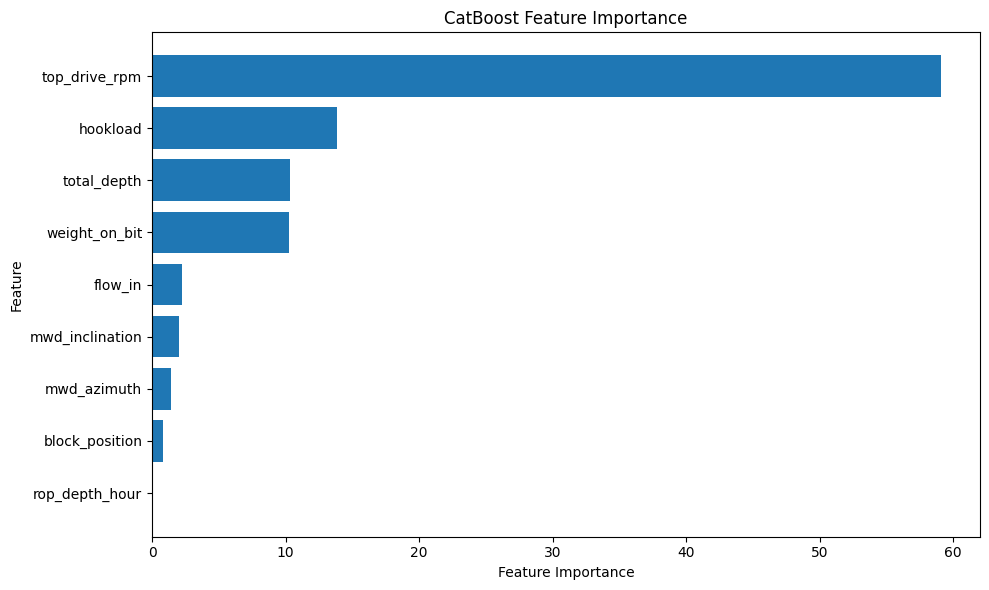

In [39]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "CatBoost Feature Importance"
)

# Most important feature at top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Actual vs Predicted Torque

The actual-versus-predicted plot evaluates how closely the model predictions follow the observed torque values in the unseen chronological test set.

The dashed diagonal represents perfect prediction.

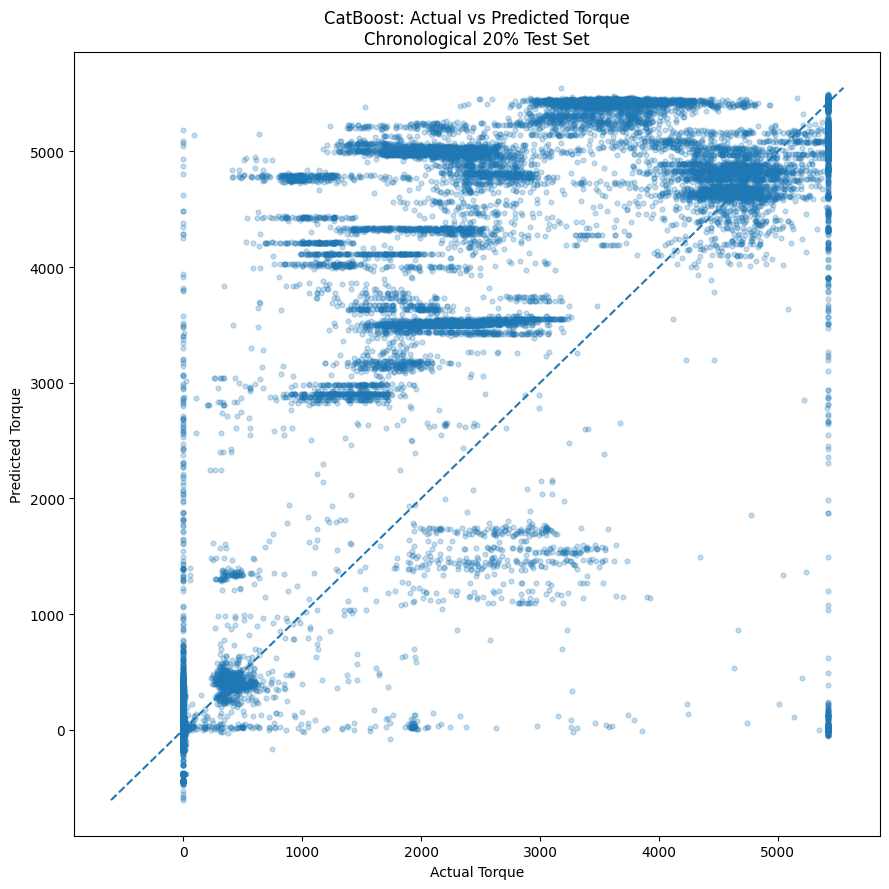

In [40]:
# ============================================================
# ACTUAL VS PREDICTED TORQUE
# ============================================================

plt.figure(figsize=(9, 9))

plt.scatter(
    y_test,
    final_cat_test_pred,
    alpha=0.25,
    s=12
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    final_cat_test_pred.min()
)

max_value = max(
    y_test.max(),
    final_cat_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Torque")
plt.ylabel("Predicted Torque")

plt.title(
    "CatBoost: Actual vs Predicted Torque\n"
    "Chronological 20% Test Set"
)

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# TEST SET RESIDUALS
# ============================================================

residuals = (
    y_test.values -
    final_cat_test_pred
)

absolute_errors = np.abs(
    residuals
)

print("=" * 70)
print("RESIDUAL STATISTICS")
print("=" * 70)

print(
    f"Mean residual : {residuals.mean():.4f}"
)

print(
    f"Std residual  : {residuals.std():.4f}"
)

print(
    f"Mean absolute error : "
    f"{absolute_errors.mean():.4f}"
)

print(
    f"Maximum absolute error : "
    f"{absolute_errors.max():.4f}"
)

RESIDUAL STATISTICS
Mean residual : -163.0426
Std residual  : 644.0241
Mean absolute error : 227.0536
Maximum absolute error : 5480.9234


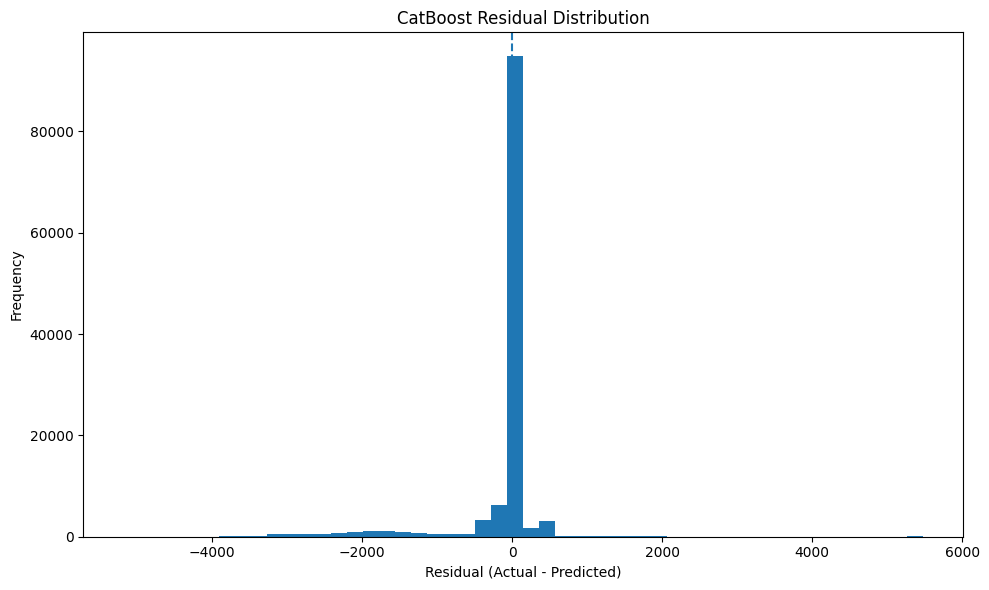

In [42]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.title(
    "CatBoost Residual Distribution"
)

plt.tight_layout()
plt.show()

## Residuals Over Time

Residuals are examined chronologically to identify systematic changes in prediction error during the unseen future period.

A systematic drift or pattern may indicate temporal changes in model performance or operating conditions.

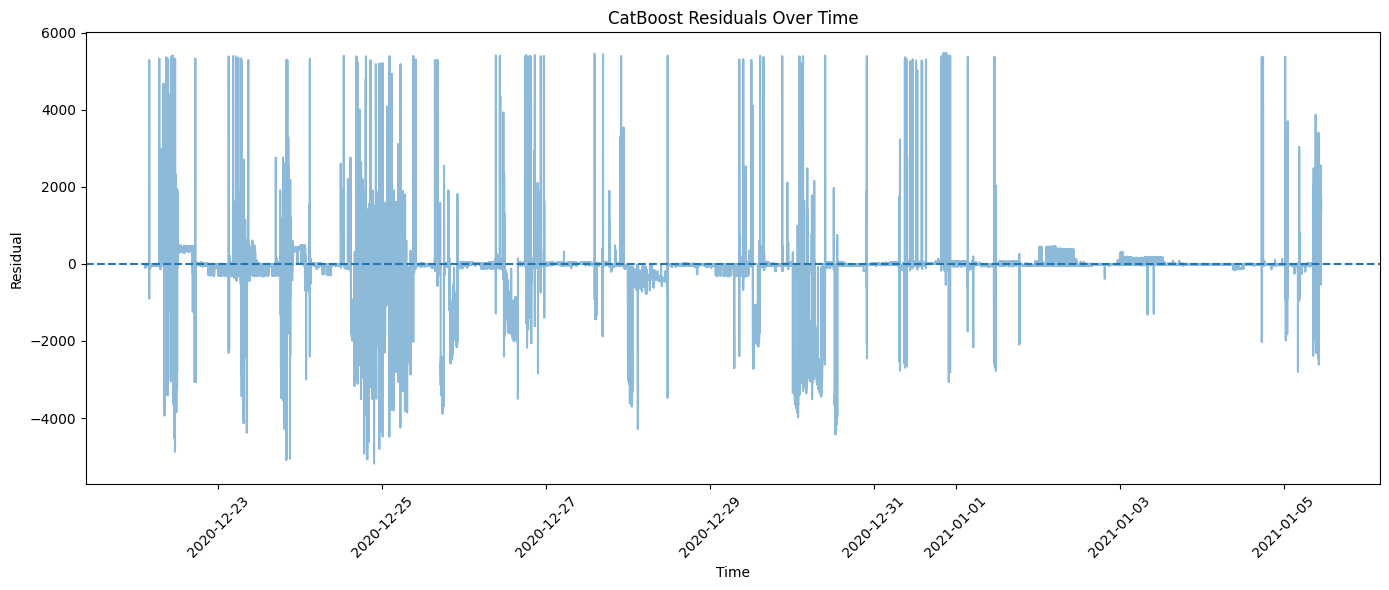

In [43]:
# ============================================================
# RESIDUALS OVER TIME
# ============================================================

test_time = df["time"].iloc[
    train_end:
].reset_index(drop=True)

residual_df = pd.DataFrame({

    "time": test_time,

    "actual": y_test.reset_index(
        drop=True
    ),

    "predicted": pd.Series(
        final_cat_test_pred
    ),

    "residual": residuals
})

plt.figure(figsize=(14, 6))

plt.plot(
    residual_df["time"],
    residual_df["residual"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Residual")

plt.title(
    "CatBoost Residuals Over Time"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Model Performance by Torque Range

The test set is divided into torque ranges to determine whether model performance changes across low-, medium-, and high-torque operating conditions.

In [44]:
# ============================================================
# PERFORMANCE BY TORQUE RANGE
# ============================================================

range_df = pd.DataFrame({

    "Actual": y_test.reset_index(
        drop=True
    ),

    "Predicted": pd.Series(
        final_cat_test_pred
    )
})

range_df["Absolute_Error"] = (
    range_df["Actual"] -
    range_df["Predicted"]
).abs()

range_df["Torque_Range"] = pd.cut(

    range_df["Actual"],

    bins=[
        -0.01,
        500,
        1000,
        1500,
        2000,
        2500,
        3000,
        4000,
        5000,
        np.inf
    ],

    labels=[
        "0–500",
        "500–1000",
        "1000–1500",
        "1500–2000",
        "2000–2500",
        "2500–3000",
        "3000–4000",
        "4000–5000",
        "5000+"
    ]
)

range_results = (
    range_df
    .groupby(
        "Torque_Range",
        observed=True
    )
    .apply(
        lambda x: pd.Series({

            "Samples": len(x),

            "MAE": mean_absolute_error(
                x["Actual"],
                x["Predicted"]
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    x["Actual"],
                    x["Predicted"]
                )
            ),

            "Mean_Actual": x["Actual"].mean(),

            "Mean_Predicted": x["Predicted"].mean()

        })
    )
    .reset_index()
)

print("=" * 70)
print("CATBOOST PERFORMANCE BY TORQUE RANGE")
print("=" * 70)

display(range_results)

CATBOOST PERFORMANCE BY TORQUE RANGE


,Torque_Range,Samples,MAE,RMSE,Mean_Actual,Mean_Predicted
0,0–500,102750.0,41.567094,142.207017,2.637588,36.140256
1,500–1000,466.0,2124.069005,2665.551159,760.824291,2681.028263
2,1000–1500,984.0,2530.957722,2685.518479,1269.106852,3745.098442
3,1500–2000,1972.0,2233.645427,2374.682474,1788.691253,3902.723130
4,2000–2500,2392.0,2003.189896,2136.640595,2252.313931,4168.729696
5,2500–3000,1289.0,1627.472663,1762.588960,2718.123578,4043.648106
6,3000–4000,2637.0,1751.132934,1801.096131,3506.043457,5052.231833
7,4000–5000,2746.0,399.152100,566.474976,4534.195808,4808.282293
8,5000+,4836.0,517.677297,1019.643097,5406.986332,4892.465614


In [45]:
# ============================================================
# BASELINE MODEL COMPARISON
# ============================================================
#
# All candidate models are compared using the same internal
# chronological validation period.
#
# The final 20% test set is intentionally excluded.
# ============================================================

final_model_comparison = pd.DataFrame({

    "Model": [
        "CatBoost",
        "LightGBM",
        "XGBoost",
        "Random Forest"
    ],

    "MAE": [
        cat_val_mae,
        lgbm_val_mae,
        xgb_val_mae,
        rf_val_mae
    ],

    "RMSE": [
        cat_val_rmse,
        lgbm_val_rmse,
        xgb_val_rmse,
        rf_val_rmse
    ],

    "R2 Score": [
        cat_val_r2,
        lgbm_val_r2,
        xgb_val_r2,
        rf_val_r2
    ]
})

final_model_comparison = (
    final_model_comparison
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL BASELINE MODEL COMPARISON - INTERNAL VALIDATION")
print("=" * 70)

display(final_model_comparison)

FINAL BASELINE MODEL COMPARISON - INTERNAL VALIDATION


,Model,MAE,RMSE,R2 Score
0,CatBoost,243.873944,584.215809,0.948908
1,LightGBM,299.785759,634.320579,0.939768
2,XGBoost,364.152263,729.674553,0.920298
3,Random Forest,360.596069,806.210179,0.902702


In [46]:
# ============================================================
# FINAL CATBOOST MODEL SUMMARY
# ============================================================

print("=" * 70)
print("FINAL CATBOOST MODEL SUMMARY")
print("=" * 70)

print("\nModel:")
print("CatBoost Regressor")

print("\nModel selection:")
print(
    "CatBoost achieved the strongest baseline performance "
    "on the internal chronological validation set."
)

print(
    "Hyperparameter tuning was then performed using the "
    "same internal validation framework."
)

print(
    "The best-performing tuned configuration was selected "
    "using validation RMSE."
)

print("\nData split:")
print("Chronological 80/20 train-test split")

print("\nDevelopment split:")
print("70% internal training")
print("10% internal validation")
print("20% final test")

print("\nTraining samples:")
print(f"{len(X_train):,}")

print("\nTest samples:")
print(f"{len(X_test):,}")

print("\nFinal Test Performance:")
print(f"MAE  : {final_cat_test_mae:.4f}")
print(f"RMSE : {final_cat_test_rmse:.4f}")
print(f"R²   : {final_cat_test_r2:.4f}")

print("\nCatBoost Validation Improvement:")
print(
    f"MAE  : {mae_improvement:.2f}%"
)

print(
    f"RMSE : {rmse_improvement:.2f}%"
)

print(
    f"R²   : {r2_improvement:.2f}%"
)

print("\n✓ Final tuned CatBoost model frozen")

FINAL CATBOOST MODEL SUMMARY

Model:
CatBoost Regressor

Model selection:
CatBoost achieved the strongest baseline performance on the internal chronological validation set.
Hyperparameter tuning was then performed using the same internal validation framework.
The best-performing tuned configuration was selected using validation RMSE.

Data split:
Chronological 80/20 train-test split

Development split:
70% internal training
10% internal validation
20% final test

Training samples:
480,287

Test samples:
120,072

Final Test Performance:
MAE  : 227.0536
RMSE : 664.3418
R²   : 0.7681

CatBoost Validation Improvement:
MAE  : 9.79%
RMSE : 2.49%
R²   : 0.26%

✓ Final tuned CatBoost model frozen


## 10. Final Model Artifact Verification

The final trained CatBoost model and its metadata are saved as persistent artifacts for later deployment and inference.

The saved artifacts are:

- `3.3_downhole_torque.pkl` — serialized final CatBoost regression model.
- `3.3_downhole_torque_metadata.json` — model configuration, feature information, data split information, and final performance metrics.

Before using the model in a deployment pipeline, the saved artifacts are reloaded and verified.

The verification process checks:

1. Whether the model file exists.
2. Whether the model can be successfully deserialized.
3. Whether the loaded model is the expected `CatBoostRegressor`.
4. Whether the metadata file exists and can be read.
5. Whether the reloaded model produces predictions identical to the original final model.

A successful verification confirms that the trained model has been correctly serialized and can be restored for future inference.

In [47]:
# ============================================================
# FINAL MODEL ARTIFACT VERIFICATION
# ============================================================

import os
import json
import joblib
import numpy as np

# ------------------------------------------------------------
# Artifact paths
# ------------------------------------------------------------

model_path = "3.3_downhole_torque.pkl"

metadata_path = "3.3_downhole_torque_metadata.json"

# ------------------------------------------------------------
# Check file existence
# ------------------------------------------------------------

print("=" * 70)
print("MODEL ARTIFACT VERIFICATION")
print("=" * 70)

print("\nChecking saved files...")

if os.path.exists(model_path):
    print(f"✓ Model file found: {model_path}")
    print(
        f"  File size: "
        f"{os.path.getsize(model_path) / 1024:.2f} KB"
    )
else:
    raise FileNotFoundError(
        f"Model file not found: {model_path}"
    )

if os.path.exists(metadata_path):
    print(f"✓ Metadata file found: {metadata_path}")
    print(
        f"  File size: "
        f"{os.path.getsize(metadata_path) / 1024:.2f} KB"
    )
else:
    raise FileNotFoundError(
        f"Metadata file not found: {metadata_path}"
    )

MODEL ARTIFACT VERIFICATION

Checking saved files...
✓ Model file found: 3.3_downhole_torque.pkl
  File size: 1442.38 KB
✓ Metadata file found: 3.3_downhole_torque_metadata.json
  File size: 1.08 KB


In [48]:
# ============================================================
# LOAD SAVED CATBOOST MODEL
# ============================================================

# Load the serialized model
loaded_cat_model = joblib.load(
    model_path
)

print("\n" + "=" * 70)
print("LOADED MODEL INFORMATION")
print("=" * 70)

print(
    f"Model type: "
    f"{type(loaded_cat_model).__name__}"
)

# Verify that the loaded model is a CatBoost regressor
if type(loaded_cat_model).__name__ == "CatBoostRegressor":
    print("✓ Model type verification passed")
else:
    print("⚠ Unexpected model type")


LOADED MODEL INFORMATION
Model type: CatBoostRegressor
✓ Model type verification passed


In [49]:
# ============================================================
# VERIFY SAVED MODEL PREDICTIONS
# ============================================================

# Predictions from the original final model
original_predictions = final_cat_model.predict(
    X_test
)

# Predictions from the reloaded .pkl model
loaded_predictions = loaded_cat_model.predict(
    X_test
)

# Calculate maximum prediction difference
max_difference = np.max(
    np.abs(
        original_predictions -
        loaded_predictions
    )
)

# Calculate mean prediction difference
mean_difference = np.mean(
    np.abs(
        original_predictions -
        loaded_predictions
    )
)

print("=" * 70)
print("MODEL PREDICTION VERIFICATION")
print("=" * 70)

print(
    f"Maximum prediction difference : "
    f"{max_difference:.12f}"
)

print(
    f"Mean prediction difference    : "
    f"{mean_difference:.12f}"
)

# ------------------------------------------------------------
# Verification threshold
# ------------------------------------------------------------

if max_difference < 1e-10:

    print("\n✓ MODEL VERIFICATION PASSED")

    print(
        "The saved .pkl model produces "
        "identical predictions to the original model."
    )

else:

    print("\n⚠ MODEL VERIFICATION WARNING")

    print(
        "The saved model predictions differ "
        "from the original model."
    )

MODEL PREDICTION VERIFICATION
Maximum prediction difference : 0.000000000000
Mean prediction difference    : 0.000000000000

✓ MODEL VERIFICATION PASSED
The saved .pkl model produces identical predictions to the original model.


In [50]:
# ============================================================
# VERIFY MODEL METADATA
# ============================================================

with open(
    metadata_path,
    "r"
) as f:

    loaded_metadata = json.load(f)

print("=" * 70)
print("MODEL METADATA VERIFICATION")
print("=" * 70)

print(
    f"Model          : "
    f"{loaded_metadata.get('model')}"
)

print(
    f"Split strategy : "
    f"{loaded_metadata.get('split_strategy')}"
)

print(
    f"Training samples : "
    f"{loaded_metadata.get('training_samples'):,}"
)

print(
    f"Test samples     : "
    f"{loaded_metadata.get('test_samples'):,}"
)

print(
    f"Target         : "
    f"{loaded_metadata.get('target')}"
)

print("\nStored test metrics:")

stored_metrics = (
    loaded_metadata.get(
        "test_metrics",
        {}
    )
)

print(
    f"MAE  : "
    f"{stored_metrics.get('MAE'):.4f}"
)

print(
    f"RMSE : "
    f"{stored_metrics.get('RMSE'):.4f}"
)

print(
    f"R²   : "
    f"{stored_metrics.get('R2'):.4f}"
)

print("\n✓ Metadata loaded successfully")

MODEL METADATA VERIFICATION
Model          : CatBoostRegressor
Split strategy : Chronological 80/20
Training samples : 480,287
Test samples     : 120,072
Target         : top_drive_torque_ft_lbs

Stored test metrics:
MAE  : 227.0536
RMSE : 664.3418
R²   : 0.7681

✓ Metadata loaded successfully


In [51]:
# ============================================================
# VERIFY STORED METRICS AGAINST CURRENT MODEL
# ============================================================

stored_mae = stored_metrics.get("MAE")
stored_rmse = stored_metrics.get("RMSE")
stored_r2 = stored_metrics.get("R2")

metric_tolerance = 1e-6

mae_match = np.isclose(
    stored_mae,
    final_cat_test_mae,
    atol=metric_tolerance
)

rmse_match = np.isclose(
    stored_rmse,
    final_cat_test_rmse,
    atol=metric_tolerance
)

r2_match = np.isclose(
    stored_r2,
    final_cat_test_r2,
    atol=metric_tolerance
)

print("=" * 70)
print("METADATA / MODEL CONSISTENCY CHECK")
print("=" * 70)

print(
    f"MAE  match : {'✓' if mae_match else '✗'}"
)

print(
    f"RMSE match : {'✓' if rmse_match else '✗'}"
)

print(
    f"R²   match : {'✓' if r2_match else '✗'}"
)

if mae_match and rmse_match and r2_match:

    print(
        "\n✓ METADATA VERIFICATION PASSED"
    )

    print(
        "Stored metrics match the final "
        "model evaluation."
    )

else:

    print(
        "\n⚠ METADATA VERIFICATION FAILED"
    )

    print(
        "Stored metadata does not match "
        "the current model results."
    )

METADATA / MODEL CONSISTENCY CHECK
MAE  match : ✓
RMSE match : ✓
R²   match : ✓

✓ METADATA VERIFICATION PASSED
Stored metrics match the final model evaluation.


## Model Artifact Verification Result

The final CatBoost model artifact has been verified by:

- Confirming that the `.pkl` file exists.
- Successfully loading the serialized model.
- Confirming that the loaded object is a `CatBoostRegressor`.
- Comparing predictions from the original and reloaded models.
- Confirming that the metadata JSON is readable.
- Confirming that the stored model metrics match the final evaluation.

A successful verification demonstrates that the final trained model can be safely restored for future inference and deployment.